# Advanced Deep Learning Concepts

#### 1. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import LearningRateScheduler

#### 2. Load Dataset

In [7]:
data = load_breast_cancer()
X= data.data
y=data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
def evaluate_model(model, history, name):
    y_pred = (model.predict(X_test)>0.5).astype(int)
    acc=accuracy_score(y_test,y_pred)
    prec=precision_score(y_test, y_pred)
    rec= recall_score(y_test, y_pred)
    f1 =f1_score(y_test,y_pred)
    print(f"\n{name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return acc, prec, rec, f1, history

#### 3. Baseline Model

In [11]:
model_basic= Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation = 'relu'),
    Dense(1, activation = 'sigmoid'),
])
model_basic.compile(optimizer='adam', loss='binary_crossentropy', metrics =['accuracy'])
history_basic = model_basic.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=0)

basic_metrics = evaluate_model(model_basic, history_basic, "Basic Model")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Basic Model Results:
Accuracy: 0.9825
Precision: 0.9726
Recall: 1.0000
F1 Score: 0.9861

Confusion Matrix:
[[41  2]
 [ 0 71]]


#### 4. Model with Dropout

In [12]:
model_dropout = Sequential([
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_dropout = model_dropout.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=0)

dropout_metrics = evaluate_model(model_dropout, history_dropout, "Dropout Model")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Dropout Model Results:
Accuracy: 0.9649
Precision: 0.9718
Recall: 0.9718
F1 Score: 0.9718

Confusion Matrix:
[[41  2]
 [ 2 69]]


#### 5. Model with Batch Normalization

In [19]:
model_bn = Sequential([
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

model_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_bn = model_bn.fit(X_train, y_train, epochs=20, validation_split=0.2, verbose=0)

bn_metrics = evaluate_model(model_bn, history_bn, "BatchNorm Model")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

BatchNorm Model Results:
Accuracy: 0.9561
Precision: 0.9583
Recall: 0.9718
F1 Score: 0.9650

Confusion Matrix:
[[40  3]
 [ 2 69]]


#### 6. Model with Learning Rate Scheduler

In [14]:
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * 0.9

lr_callback = LearningRateScheduler(scheduler)

model_lr = Sequential([
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lr.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_lr = model_lr.fit(X_train, y_train, epochs=20, validation_split=0.2, callbacks=[lr_callback], verbose=0)

lr_metrics = evaluate_model(model_lr, history_lr, "LR Scheduler Model")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

LR Scheduler Model Results:
Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1 Score: 0.9790

Confusion Matrix:
[[41  2]
 [ 1 70]]


#### 7. Compare Results (Table)

In [15]:
results = pd.DataFrame({
    "Model": ["Basic", "Dropout", "BatchNorm", "LR Scheduler"],
    "Accuracy": [basic_metrics[0], dropout_metrics[0], bn_metrics[0], lr_metrics[0]],
    "Precision": [basic_metrics[1], dropout_metrics[1], bn_metrics[1], lr_metrics[1]],
    "Recall": [basic_metrics[2], dropout_metrics[2], bn_metrics[2], lr_metrics[2]],
    "F1 Score": [basic_metrics[3], dropout_metrics[3], bn_metrics[3], lr_metrics[3]],
})

print("\nComparison Table:")
print(results)


Comparison Table:
          Model  Accuracy  Precision    Recall  F1 Score
0         Basic  0.982456   0.972603  1.000000  0.986111
1       Dropout  0.964912   0.971831  0.971831  0.971831
2     BatchNorm  0.956140   0.945946  0.985915  0.965517
3  LR Scheduler  0.973684   0.972222  0.985915  0.979021


#### 8. Plot Accuracy & Loss

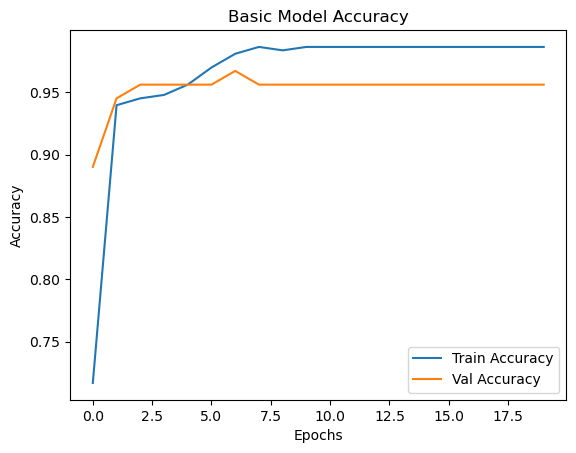

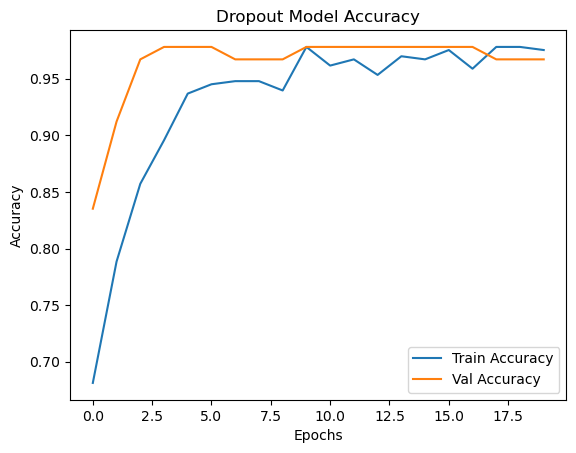

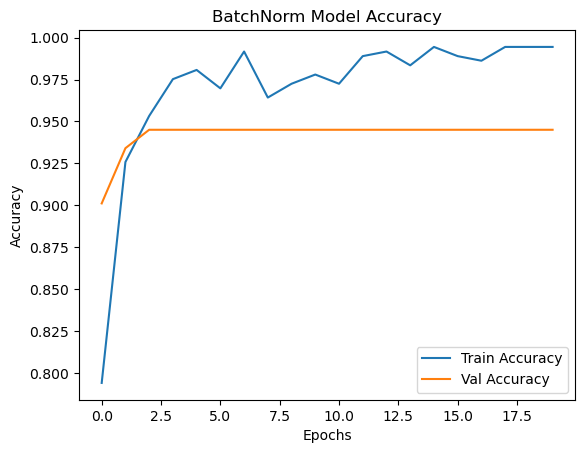

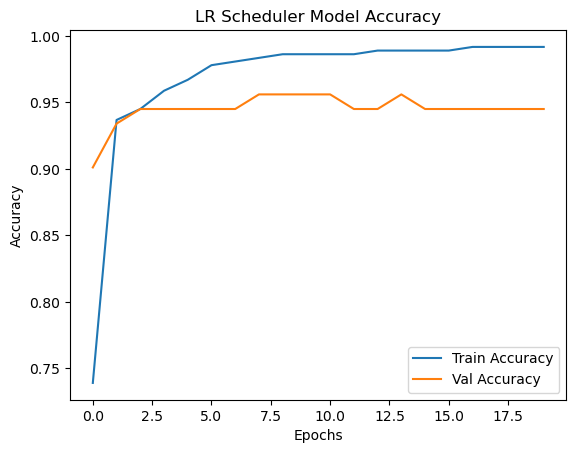

In [16]:
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(history_basic, "Basic Model Accuracy")
plot_history(history_dropout, "Dropout Model Accuracy")
plot_history(history_bn, "BatchNorm Model Accuracy")
plot_history(history_lr, "LR Scheduler Model Accuracy")